In [1]:
%pip install gensim rank-bm25 pandas numpy sentence-transformers faiss-cpu Sastrawi


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================
import os
import re
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict, Counter

from gensim.models import Word2Vec
from gensim.models.fasttext import load_facebook_vectors
from rank_bm25 import BM25Okapi

from sentence_transformers import SentenceTransformer
import torch
import faiss

import logging
logging.getLogger("gensim").setLevel(logging.ERROR)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


c:\Users\dela puspita\Documents\INFORMATIKA SMT 7\SKRIPSI\program\venv-skripsi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [3]:
# ============================================================
# 1. LOAD DATA DOKUMEN DARI GOOGLE SHEETS
# ============================================================
DATA_URL = "https://docs.google.com/spreadsheets/d/1gTmTtyRO5SmQsq4_QdB1ZnUdSUNmoNyL7MciKfVdgtE/export?format=csv&gid=527481706"

docs = pd.read_csv(DATA_URL)
print("Kolom dataset:", list(docs.columns))
print("Jumlah dokumen:", len(docs))

# doc_id = index (0..N-1), HARUS sama dengan yang dipakai saat build FAISS di Colab
docs = docs.reset_index(drop=True)
docs["doc_id"] = docs.index

TEXT_BM25_COL = "text_bm25"
TEXT_W2V_COL  = "text_word2vec"

if TEXT_BM25_COL not in docs.columns:
    raise ValueError(f"Kolom {TEXT_BM25_COL} tidak ditemukan.")

if TEXT_W2V_COL not in docs.columns:
    raise ValueError(f"Kolom {TEXT_W2V_COL} tidak ditemukan.")

docs[TEXT_BM25_COL] = docs[TEXT_BM25_COL].fillna("")
docs[TEXT_W2V_COL]  = docs[TEXT_W2V_COL].fillna("")

docs[["doc_id", "title", TEXT_BM25_COL, TEXT_W2V_COL]].head()


Kolom dataset: ['url', 'title', 'abstract', 'faculty', 'department', 'text_semantic', 'text_bm25', 'text_word2vec']
Jumlah dokumen: 15326


,doc_id,title,text_bm25,text_word2vec
0,0,PENERAPAN METODE CLARKE AND WRIGHT SAVING HEUR...,penerapan metode clarke and wright saving heur...,penerapan metode clarke and wright saving heur...
1,1,OPINION SHOPPING SEBAGAI PEMODERASI PENGARUH F...,opinion shopping sebagai pemoderasi pengaruh f...,opinion shopping sebagai pemoderasi pengaruh f...
2,2,PREDIKSI PENYAKIT JANTUNG MENGGUNAKAN ALGORITM...,prediksi penyakit jantung menggunakan algoritm...,prediksi penyakit jantung menggunakan algoritm...
3,3,IDENTIFIKASI TANDA TANGAN DENGAN METODE CONVOL...,identifikasi tanda tangan dengan metode convol...,identifikasi tanda tangan dengan metode convol...
4,4,IDENTIFIKASI MATA UANG LOGAM MENGGUNAKAN SEGME...,identifikasi mata uang logam menggunakan segme...,identifikasi mata uang logam menggunakan segme...


In [4]:
# ============================================================
# 2. TOKENISASI & DOCUMENT FREQUENCY UNTUK WORD2VEC
# ============================================================

def simple_tokenize(text):
    text = str(text).lower()
    tokens = re.findall(r"[a-z0-9_]+", text)
    return [t for t in tokens if len(t) > 2]

docs_tokens_w2v = [simple_tokenize(t) for t in docs[TEXT_W2V_COL]]

doc_freq = Counter()
for sent in docs_tokens_w2v:
    for tok in set(sent):
        doc_freq[tok] += 1

print("Jumlah dokumen:", len(docs_tokens_w2v))
print("Contoh DF:", list(doc_freq.items())[:10])


Jumlah dokumen: 15326
Contoh DF: [('itu', 3954), ('memiliki', 5334), ('terpendek', 17), ('pengalaman', 550), ('hasil', 11213), ('sebanyak', 2214), ('kendaraan', 314), ('perkiraan', 34), ('sudah', 929), ('awal', 556)]


In [4]:
# ============================================================
# DETAIL QE 2. TOKENISASI UNTUK QE
# ============================================================
def simple_tokenize(text):
    text = str(text).lower()
    tokens = re.findall(r"[a-z0-9_]+", text)
    return [t for t in tokens if len(t) > 2]

docs_tokens_w2v = [simple_tokenize(t) for t in docs[TEXT_W2V_COL]]

print("Contoh token dokumen:", docs_tokens_w2v[0][:10])


Contoh token dokumen: ['penerapan', 'metode', 'clarke', 'and', 'wright', 'saving', 'heuristic', 'dalam', 'menentukan', 'rute']


In [5]:
# ============================================================
# DETAIL QE 3. HITUNG DOCUMENT FREQUENCY
# ============================================================
doc_freq = Counter()
for tokens in docs_tokens_w2v:
    for tok in set(tokens):
        doc_freq[tok] += 1

N_DOCS = len(docs_tokens_w2v)
print("Jumlah dokumen:", N_DOCS)


Jumlah dokumen: 15326


In [6]:
# ============================================================
# 3. BM25 UNTUK TEXT_BM25 (OPSIONAL, TAPI KEPERLUAN PERBANDINGAN)
# ============================================================
corpus_tokens_bm25 = [simple_tokenize(t) for t in docs[TEXT_BM25_COL]]
bm25 = BM25Okapi(corpus_tokens_bm25)
doc_ids = docs["doc_id"].tolist()

print("BM25 siap. Jumlah dokumen:", len(doc_ids))


BM25 siap. Jumlah dokumen: 15326


In [ ]:
# ============================================================
# 4. LOAD PRETRAINED FASTTEXT (KEYED VECTORS)
# ============================================================
FASTTEXT_BIN = "cc.id.300.bin"  # pastikan file ini ada di folder proyek

if not os.path.exists(FASTTEXT_BIN):
    raise FileNotFoundError("File cc.id.300.bin tidak ditemukan. Letakkan di folder proyek.")

print("Memuat vektor FastText (butuh waktu, file besar)...")
ft = load_facebook_vectors(FASTTEXT_BIN)
print("Dimensi vektor FastText:", ft.vector_size)
print("Contoh vocab:", list(ft.key_to_index.keys())[:10])

# ============================================================
# 5. WORD2VEC: INIT DARI FASTTEXT + FINE-TUNE DI KORPUS SKRIPSI
# ============================================================
w2v_model = Word2Vec(
    vector_size=ft.vector_size,  # 300
    window=8,
    min_count=5,
    workers=4,
    sg=1,   # skip-gram
)

print("Membangun vocab Word2Vec dari text_word2vec...")
w2v_model.build_vocab(docs_tokens_w2v)
print("Ukuran vocab Word2Vec (awal):", len(w2v_model.wv.key_to_index))

# Inisialisasi bobot embedding Word2Vec dengan vektor FastText
common_words = set(w2v_model.wv.key_to_index.keys()).intersection(set(ft.key_to_index.keys()))
print("Jumlah kata yang di-init dari FastText:", len(common_words))

for w in common_words:
    idx = w2v_model.wv.key_to_index[w]
    w2v_model.wv.vectors[idx] = ft[w]

print("Inisialisasi dari FastText selesai.")

# Fine-tuning Word2Vec di korpus skripsi
epochs = 10
print("Mulai fine-tuning Word2Vec...")
w2v_model.train(
    docs_tokens_w2v,
    total_examples=len(docs_tokens_w2v),
    epochs=epochs
)
print("Fine-tuning selesai.")

w2v = w2v_model.wv
print("Ukuran vocab Word2Vec (final):", len(w2v.key_to_index))


In [7]:
# ============================================================
# DETAIL QE 4. LOAD FASTTEXT PRETRAINED
# ============================================================
FASTTEXT_BIN = "cc.id.300.bin"

if not os.path.exists(FASTTEXT_BIN):
    raise FileNotFoundError("File FastText tidak ditemukan")

print("Loading FastText...")
ft = load_facebook_vectors(FASTTEXT_BIN)

print("Dimensi FastText:", ft.vector_size)


Loading FastText...
Dimensi FastText: 300


In [8]:
# ============================================================
# DETAIL QE 5. INIT WORD2VEC DARI FASTTEXT
# ============================================================
w2v_model = Word2Vec(
    vector_size=ft.vector_size,
    window=8, #8
    min_count=5, #5
    workers=4,
    sg=1,
)

print("Build vocab Word2Vec...")
w2v_model.build_vocab(docs_tokens_w2v)

print("Vocab awal Word2Vec:", len(w2v_model.wv))


Build vocab Word2Vec...
Vocab awal Word2Vec: 19196


In [9]:
# DETAIL QE

common_words = set(w2v_model.wv.key_to_index).intersection(ft.key_to_index)
print("Kata di-init dari FastText:", len(common_words))

for word in common_words:
    w2v_model.wv[word] = ft[word]

print("Inisialisasi embedding selesai")


Kata di-init dari FastText: 17286
Inisialisasi embedding selesai


In [10]:
# ============================================================
# DETAIL QE 6. FINE-TUNING WORD2VEC
# ============================================================
epochs = 10

w2v_model.train(
    docs_tokens_w2v,
    total_examples=len(docs_tokens_w2v),
    epochs=epochs
)

w2v = w2v_model.wv
print("Vocab akhir Word2Vec:", len(w2v))


Vocab akhir Word2Vec: 19196


In [11]:
# ============================================================
# DETAIL QE 7. FILTER QE (UPDATED: Sastrawi Stopwords)
# ============================================================

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ----------------------------
# STOPWORDS (Sastrawi + Custom)
# ----------------------------
factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())

custom_stopwords = {
    "dan","atau","yang","dengan","pada","di","ke","dari", "untuk","dalam","sebagai","adalah","itu","ini"
}

STOPWORDS = sastrawi_stopwords.union(custom_stopwords)

# ----------------------------
# OPTIONAL: NORMALIZATION
# ----------------------------
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stemmer = StemmerFactory().create_stemmer()

def normalize(word):
    return stemmer.stem(word.lower())


# ----------------------------
# PREFIX RULE
# ----------------------------
COMMON_PREFIXES = ("me", "di", "pe", "ke", "ber", "ter")

def is_morphological_variant(base, cand):
    for p in COMMON_PREFIXES:
        if cand.startswith(p) and cand[len(p):] == base:
            return True
    return False


# ----------------------------
# MAIN FILTER QE
# ----------------------------
def is_valid_expansion(
    word,
    base_tokens,
    min_df=5,
    max_df_ratio=0.15
):
    w = normalize(word)

    # 1. Jangan sama dengan query asli
    if w in [normalize(bt) for bt in base_tokens]:
        return False

    # 2. Stopwords filtering
    if w in STOPWORDS:
        return False

    # 3. Basic filter
    if word.isdigit() or len(word) < 3:
        return False

    # 4. Document frequency filter
    if doc_freq.get(word, 0) < min_df:
        return False

    if doc_freq.get(word, 0) / N_DOCS > max_df_ratio:
        return False

    # 5. Morphological variant filter
    for bt in base_tokens:
        if is_morphological_variant(normalize(bt), w):
            return False

    return True

In [12]:
# ============================================================
# DETAIL QE 8. QUERY EXPANSION HYBRID
# ============================================================
def expand_query_hybrid(
    query,
    topn_per_term=20,
    min_sim=0.60,
    max_expansion=10
):
    base_tokens = simple_tokenize(query)
    expansions = []

    for token in base_tokens:
        # Word2Vec utama
        if token in w2v:
            candidates = w2v.most_similar(token, topn=topn_per_term)
        # FastText hanya fallback
        elif token in ft and doc_freq.get(token, 0) >= 5:
            candidates = ft.most_similar(token, topn=topn_per_term)
        else:
            continue

        for cand, sim in candidates:
            if sim < min_sim:
                continue
            if not is_valid_expansion(cand, base_tokens):
                continue
            if cand in expansions:
                continue

            expansions.append((cand))
            if len(expansions) >= max_expansion:
                break

        if len(expansions) >= max_expansion:
            break

    return {
        "query_asli": query,
        "token_query": base_tokens,
        "hasil_expansi": expansions,
        "query_ekspansi": base_tokens 
    }


In [13]:
q = "redesain tps"

result = expand_query_hybrid(q)

result

{'query_asli': 'redesain tps',
 'token_query': ['redesain', 'tps'],
 'hasil_expansi': ['reuse'],
 'query_ekspansi': ['redesain', 'tps']}

In [15]:
# ============================================================
# QE - WORD2VEC ONLY
# ============================================================

def expand_query_w2v_only(
    query,
    topn_per_term=20,
    min_sim=0.60,
    max_expansion=10
):
    base_tokens = simple_tokenize(query)
    expansions = []

    for token in base_tokens:
        if token not in w2v:
            continue

        candidates = w2v.most_similar(token, topn=topn_per_term)

        for cand, sim in candidates:
            if sim < min_sim:
                continue
            if not is_valid_expansion(cand, base_tokens):
                continue
            if cand in expansions:
                continue

            expansions.append((cand, round(sim, 2)))

            if len(expansions) >= max_expansion:
                break

        if len(expansions) >= max_expansion:
            break

    return {
        "query_asli": query,
        "token_query": base_tokens,
        "hasil_expansi": expansions,
        "query_ekspansi": base_tokens + [e[0] for e in expansions]
    }


# ================== TEST ==================
q = "redesain tps"

result_w2v = expand_query_w2v_only(q)

print("=== WORD2VEC QE ===")
print("Query   :", result_w2v["query_asli"])
print("Token   :", result_w2v["token_query"])
print("Expand  :", result_w2v["hasil_expansi"])
print("Final   :", result_w2v["query_ekspansi"])

result_w2v

=== WORD2VEC QE ===
Query   : redesain tps
Token   : ['redesain', 'tps']
Expand  : [('timbulan', 0.61), ('sampah', 0.61)]
Final   : ['redesain', 'tps', 'timbulan', 'sampah']


{'query_asli': 'redesain tps',
 'token_query': ['redesain', 'tps'],
 'hasil_expansi': [('timbulan', 0.61), ('sampah', 0.61)],
 'query_ekspansi': ['redesain', 'tps', 'timbulan', 'sampah']}

In [16]:
# ============================================================
# QE - FASTTEXT ONLY (FIXED)
# ============================================================

def expand_query_fasttext_only(
    query,
    topn_per_term=20,
    min_sim=0.60,
    max_expansion=10
):
    base_tokens = simple_tokenize(query)
    expansions = []

    for token in base_tokens:
        # handle case sensitivity
        token_ft = token
        if token_ft not in ft:
            if token.upper() in ft:
                token_ft = token.upper()
            else:
                continue

        candidates = ft.most_similar(token_ft, topn=topn_per_term)

        for cand, sim in candidates:
            if sim < min_sim:
                continue
            if not is_valid_expansion(cand, base_tokens):
                continue
            if cand in expansions:
                continue

            expansions.append((cand, round(sim, 2)))

            if len(expansions) >= max_expansion:
                break

        if len(expansions) >= max_expansion:
            break

    return {
        "query_asli": query,
        "token_query": base_tokens,
        "hasil_expansi": expansions,
        "query_ekspansi": base_tokens + [e[0] for e in expansions]
    }


# ================== TEST ==================
q = "redesain tps"

result_ft = expand_query_fasttext_only(q)

print("=== FASTTEXT QE ===")
print("Query   :", result_ft["query_asli"])
print("Token   :", result_ft["token_query"])
print("Expand  :", result_ft["hasil_expansi"])
print("Final   :", result_ft["query_ekspansi"])

result_ft

=== FASTTEXT QE ===
Query   : redesain tps
Token   : ['redesain', 'tps']
Expand  : [('redesign', 0.73), ('desain', 0.72)]
Final   : ['redesain', 'tps', 'redesign', 'desain']


{'query_asli': 'redesain tps',
 'token_query': ['redesain', 'tps'],
 'hasil_expansi': [('redesign', 0.73), ('desain', 0.72)],
 'query_ekspansi': ['redesain', 'tps', 'redesign', 'desain']}

In [132]:
# # QE INDOSBERT

# from sentence_transformers import SentenceTransformer
# import faiss
# import numpy as np
# import os

# DEVICE = "cpu"  # atau "cpu"

# MODEL_DIR_FT = "indosbert_finetuned_title_abs"
# INDEX_DIR_FT = "indexes_finetuned"

# model_ft = SentenceTransformer(MODEL_DIR_FT, device=DEVICE)
# index_ft = faiss.read_index(os.path.join(INDEX_DIR_FT, "semantic_index.faiss"))
# doc_ids_ft = np.load(os.path.join(INDEX_DIR_FT, "doc_ids.npy")).tolist()


In [ ]:
# def retrieve_top_docs_ft(query, model, index, doc_ids, top_k=5):
#     query_emb = model.encode(
#         [query],
#         normalize_embeddings=True
#     )
    
#     D, I = index.search(query_emb, top_k)
    
#     retrieved_doc_ids = [doc_ids[i] for i in I[0]]
#     scores = D[0]

#     return retrieved_doc_ids, scores


In [ ]:
# def get_candidate_texts_from_docs(doc_ids, docs):
#     texts = []
#     for doc_id in doc_ids:
#         row = docs[docs["doc_id"] == doc_id].iloc[0]
        
#         # kalau abstract ada
#         if "abstract" in row:
#             text = f"{row['title']} {row['abstract']}"
#         else:
#             text = row["title"]
        
#         texts.append(text)
#     return texts

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# def extract_keywords_from_docs(texts, top_n=5):
#     vectorizer = TfidfVectorizer(
#         ngram_range=(1, 2),
#         max_features=500
#     )
    
#     tfidf_matrix = vectorizer.fit_transform(texts)
#     feature_names = vectorizer.get_feature_names_out()
    
#     scores = tfidf_matrix.sum(axis=0).A1
#     ranked = sorted(
#         zip(feature_names, scores),
#         key=lambda x: x[1],
#         reverse=True
#     )
    
#     keywords = [w for w, _ in ranked[:top_n]]
#     return keywords


In [ ]:
# def qe_indosbert_finetuned(
#     query,
#     model,
#     index,
#     doc_ids,
#     docs,
#     top_k_docs=5,
#     top_n_keywords=5
# ):
#     # 1. Retrieve dokumen relevan (semantic)
#     query_emb = model.encode(
#         [query],
#         normalize_embeddings=True,
#         device=DEVICE
#     )
    
#     scores, idx = index.search(query_emb, top_k_docs)
#     retrieved_doc_ids = [doc_ids[i] for i in idx[0]]
    
#     # 2. Ambil teks dokumen
#     candidate_texts = get_candidate_texts_from_docs(
#         retrieved_doc_ids, docs
#     )
    
#     # 3. Ekstraksi keyword
#     vectorizer = TfidfVectorizer(
#         ngram_range=(1, 2),
#         max_features=500
#     )
    
#     tfidf = vectorizer.fit_transform(candidate_texts)
#     feature_names = vectorizer.get_feature_names_out()
#     scores_kw = tfidf.sum(axis=0).A1
    
#     ranked = sorted(
#         zip(feature_names, scores_kw),
#         key=lambda x: x[1],
#         reverse=True
#     )
    
#     STOPWORDS_ID = set([
#     "yang","dan","untuk","dengan","pada","ini","itu","dari","ke",
#     "dalam","sebagai","adalah","oleh","atau","di","akan","karena"
#     ])

#     expansion_terms = [
#         w for w,_ in ranked
#         if w not in STOPWORDS_ID
#         and len(w) > 3
#     ][:top_n_keywords]

    
#     # 4. Gabungkan query
#     query_tokens = query.lower().split()
#     expanded_query = list(dict.fromkeys(query_tokens + expansion_terms))
    
#     return {
#         "query_asli": query,
#         "doc_kandidat": retrieved_doc_ids,
#         "hasil_expansi": expansion_terms,
#         "query_ekspansi": expanded_query
#     }


In [ ]:
# qe_indosbert_finetuned(
#     query="kendali perangkat jarak jauh",
#     model=model_ft,
#     index=index_ft,
#     doc_ids=doc_ids_ft,
#     docs=docs
# )


{'query_asli': 'kendali perangkat jarak jauh',
 'doc_kandidat': [12520, 12517, 14880, 14827, 7897],
 'hasil_expansi': ['algoritma', 'sensor', 'menggunakan', 'jalan', 'cuaca'],
 'query_ekspansi': ['kendali',
  'perangkat',
  'jarak',
  'jauh',
  'algoritma',
  'sensor',
  'menggunakan',
  'jalan',
  'cuaca']}

In [ ]:
# # ============================================================
# # 6. QUERY EXPANSION DENGAN WORD2VEC + FALLBACK FASTTEXT
# # ============================================================

# STOPWORDS = set([
#     "dan", "atau", "yang", "dengan", "pada", "di", "ke", "dari",
#     "untuk", "dalam", "sebagai", "adalah", "itu", "ini", "the",
#     "of", "a", "an", "to", "on", "by", "for", "at", "from"
# ])

# def is_valid_expansion(word: str, base_tokens):
#     if word in base_tokens:
#         return False
#     if len(word) < 3:
#         return False
#     if word.isdigit():
#         return False
#     if word in STOPWORDS:
#         return False
#     return True

# def expand_query_w2v(
#     query: str,
#     topn_per_term: int = 20,
#     min_sim: float = 0.60,
#     max_expansion: int = 10,
#     min_df: int = 2
# ):
#     tokens = simple_tokenize(query)
#     expansions = []

#     for t in tokens:
#         use_model = None
#         if t in w2v:
#             use_model = w2v
#         elif t in ft:
#             use_model = ft
#         else:
#             continue

#         try:
#             candidates = use_model.most_similar(t, topn=topn_per_term)
#         except KeyError:
#             continue

#         for w, sim in candidates:
#             if sim < min_sim:
#                 continue
#             if not is_valid_expansion(w, tokens):
#                 continue
#             if w in expansions:
#                 continue
#             if doc_freq.get(w, 0) < min_df:
#                 continue

#             expansions.append(w)
#             if len(expansions) >= max_expansion:
#                 break

#         if len(expansions) >= max_expansion:
#             break

#     return tokens, expansions


In [37]:
# BM25 + QE

def bm25_qe_search_df(query, topk=10):
    qe_result = expand_query_hybrid(query)

    tokens = qe_result["token_query"]
    expansions = qe_result["hasil_expansi"]

    terms = tokens + expansions if expansions else tokens

    scores = bm25.get_scores(terms)
    ranked_idx = np.argsort(scores)[::-1][:topk]
    ranked_doc_ids = [doc_ids[i] for i in ranked_idx]

    rank_map = {d: i+1 for i, d in enumerate(ranked_doc_ids)}

    res = docs[docs["doc_id"].isin(ranked_doc_ids)][["doc_id", "title", "url"]].copy()
    res["rank"] = res["doc_id"].map(rank_map)
    res["score"] = res["doc_id"].map({
        d: scores[i] for d, i in zip(ranked_doc_ids, ranked_idx)
    })

    res = res.sort_values("rank")

    print("BM25+QE tokens:", tokens)
    print("BM25+QE exp   :", expansions)

    pd.set_option("display.max_colwidth", None)

    return res[["rank", "doc_id", "title", "url", "score"]]


bm25_qe_search_df("SISTEM PENCARIAN HASIL PENELITIAN SKRIPSI MENGGUNAKAN WEIGHTED TREE SIMILARITY DAN CONTENT BASED FILTERING", topk=25)

BM25+QE tokens: ['sistem', 'pencarian', 'hasil', 'penelitian', 'skripsi', 'menggunakan', 'weighted', 'tree', 'similarity', 'dan', 'content', 'based', 'filtering']
BM25+QE exp   : ['weighting', 'additive', 'perankingan', 'attribute', 'threshold', 'winters', 'selection', 'exponential', 'jaccard', 'entropy']


,rank,doc_id,title,url,score
6194,1,6194,SISTEM PENCARIAN HASIL PENELITIAN SKRIPSI MENGGUNAKAN WEIGHTED TREE SIMILARITY DAN CONTENT BASED FILTERING,https://repository.upnjatim.ac.id/26734/,74.066412
2969,2,2969,Implementasi Case-Based Reasoning untuk Diagnosis Awal Penyakit Anjing Menggunakan Similaritas Jaccard dan Sorensen-Dice Coefficient,https://repository.upnjatim.ac.id/18804/,57.603022
8136,3,8136,Pemanfaatan Bot Discord Dalam Memberikan Rekomendasi Manhwa dengan Metode Content-Based Filtering,https://repository.upnjatim.ac.id/33093/,51.970531
7174,4,7174,Implementasi Metode Collaborative Filtering Menggunakan Cosine Similarity dan Jaccard Similarity pada Sistem,https://repository.upnjatim.ac.id/29472/,49.344401
5588,5,5588,KOMPARASI KINERJA METODE COSINE DAN JACCARD SIMILARITY DALAM CONTENT-BASED RECOMMENDATION SYSTEMS (CBRS) PADA APLIKASI EVENTHINGS,https://repository.upnjatim.ac.id/25453/,48.997127
7175,6,7175,Sistem Pendukung Keputusan Mata Pelajaran Pilihan Siswa Menggunakan Metode Simple Additive Weighting dan Weighted Product,https://repository.upnjatim.ac.id/29473/,47.600139
9173,7,9173,Rancang Bangun Sistem Rekomendasi Produk Skincare Menggunakan Metode Hybrid Collaborative Filtering Berbasis Android,https://repository.upnjatim.ac.id/36435/,41.663868
7561,8,7561,SISTEM PENDUKUNG KEPUTUSAN PEMILIHAN SUPPLIER DALAM PENGADAAN BARANG MENGGUNAKAN METODE ANALYTICAL HIERARCHY PROCESS DAN SIMPLE ADDITIVE WEIGHTING (STUDI KASUS : APOTEK MERPATI 1 SIDOARJO),https://repository.upnjatim.ac.id/3135/,36.985856
7586,9,7586,SISTEM PENDUKUNG KEPUTUSAN PROMOSI KENAIKAN JABATAN FUNGSIONAL TENAGA KESEHATAN DENGAN METODE SAW (SIMPLE ADDITIVE WEIGHTING) BERBASIS WEB DI BIDANG SUMBER DAYA KESEHATAN (STUDI KASUS DINAS KESEHATAN KABUPATEN BOJONEGORO),https://repository.upnjatim.ac.id/3154/,35.997407
3998,10,3998,SISTEM PENDUKUNG KEPUTUSAN PEMILIHAN SISWA KELAS UNGGULAN MENGGUNAKAN METODE SIMPLE ADDITIVE WEIGHTING (STUDI KASUS : SMA MUHAMMADIYAH 1 TAMAN),https://repository.upnjatim.ac.id/2076/,35.466851


In [36]:
#BASE SEMANTIC

INDEX_DIR_BASE = "indexes_base"
MODEL_NAME_BASE = "firqaaa/indo-sentence-bert-base"

model_base = SentenceTransformer(MODEL_NAME_BASE, device=DEVICE)
index_base = faiss.read_index(os.path.join(INDEX_DIR_BASE, "semantic_index.faiss"))
doc_ids_base = np.load(os.path.join(INDEX_DIR_BASE, "doc_ids.npy")).tolist()

def semantic_base_df(query, topk=10):
    q_emb = model_base.encode([query], convert_to_numpy=True, normalize_embeddings=True, device=DEVICE)
    scores, idx = index_base.search(q_emb, topk)
    ranked_doc_ids = [doc_ids_base[i] for i in idx[0]]
    rank_map = {d:i+1 for i,d in enumerate(ranked_doc_ids)}

    res = docs[docs["doc_id"].isin(ranked_doc_ids)][["doc_id","title","url"]].copy()
    res["rank"] = res["doc_id"].map(rank_map)
    res["score"] = res["doc_id"].map({d:s for d,s in zip(ranked_doc_ids, scores[0])})
    return res.sort_values("rank")[["rank","doc_id","title","url","score"]]

semantic_base_df("Sistem Pencarian Hasil Penelitian Skripsi menggunakan Weighted Tree Similarity dan Content Based Filtering", topk=25)


,rank,doc_id,title,url,score
6194,1,6194,SISTEM PENCARIAN HASIL PENELITIAN SKRIPSI MENGGUNAKAN WEIGHTED TREE SIMILARITY DAN CONTENT BASED FILTERING,https://repository.upnjatim.ac.id/26734/,0.732687
14765,2,14765,Analisis Kegunaan Pada Website Program Studi Agroteknologi Universitas Pembangunan Nasional “Veteran” Jawa Timur Menggunakan Pendekatan System Usability Scale (SUS),https://repository.upnjatim.ac.id/8521/,0.724761
14708,3,14708,Analisis Usability pada Website Program Studi Hubungan Internasional Menggunakan Metode System Usability Scale,https://repository.upnjatim.ac.id/8431/,0.707190
15230,4,15230,ANALISA SISTEM INFORMASI RISET DAN PENGABDIAN MASYARAKAT BERBASIS SERVICE ORIENTED SOFTWARE ENGINEERING,https://repository.upnjatim.ac.id/968/,0.703261
11593,5,11593,ANALISIS PERHITUNGAN USABILITY WEBSITE SISTEM INFORMASI PELAYANAN (SIMPEL) BADAN NARKOTIKA NASIONAL PROVINSI JAWA TIMUR MENGGUNAKAN SYSTEM USABILITY SCALE (SUS),https://repository.upnjatim.ac.id/41661/,0.701322
2099,6,2099,ANALISIS USABILITY PADA WEBSITE MAN KOTA MOJOKERTO MENGGUNAKAN MODEL SYSTEM USABILITY SCALE (SUS),https://repository.upnjatim.ac.id/16358/,0.699610
10340,7,10340,ANALISIS PERBANDINGAN KLASIFIKASI CITRA PENYAKIT PADA DAUN JERUK MENGGUNAKAN ALGORITMA MOBILENETV3-LARGE DAN EFFICIENTNET-B0,https://repository.upnjatim.ac.id/38888/,0.698236
5985,8,5985,SISTEM PENDUKUNG KEPUTUSAN PENENTUAN PERWAKILAN OLIMPIADE AKADEMIK MENGGUNAKAN METODE AHP-SAW (STUDI KASUS: MTS. YPPMI ARJASA),https://repository.upnjatim.ac.id/26270/,0.696708
7802,9,7802,"OPTIMASI ALGORITMA NAÏVE BAYES, RANDOM FOREST, DAN LOGISTIC REGRESSION MENGGUNAKAN METODE MAJORITY VOTE UNTUK ANALISIS SENTIMEN PADA ULASAN APLIKASI SATUSEHAT",https://repository.upnjatim.ac.id/32287/,0.693152
1409,10,1409,Pengelompokan Topik Skripsi Menggunakan Algoritma Agglomerative Hierarchical Clustering di Program Studi Sistem Informasi UPN Veteran Jawa Timur,https://repository.upnjatim.ac.id/14535/,0.687528


In [35]:
# SEMANTIC FINETUNED

MODEL_DIR_FT = "indosbert_finetuned_title_abs"
INDEX_DIR_FT = "indexes_finetuned"

model_ft = SentenceTransformer(MODEL_DIR_FT, device=DEVICE)
index_ft = faiss.read_index(os.path.join(INDEX_DIR_FT, "semantic_index.faiss"))
doc_ids_ft = np.load(os.path.join(INDEX_DIR_FT, "doc_ids.npy")).tolist()

def semantic_ft_df(query, topk=10):
    q_emb = model_ft.encode([query], convert_to_numpy=True, normalize_embeddings=True, device=DEVICE)
    scores, idx = index_ft.search(q_emb, topk)
    ranked_doc_ids = [doc_ids_ft[i] for i in idx[0]]
    rank_map = {d:i+1 for i,d in enumerate(ranked_doc_ids)}

    res = docs[docs["doc_id"].isin(ranked_doc_ids)][["doc_id","title","url"]].copy()
    res["rank"] = res["doc_id"].map(rank_map)
    res["score"] = res["doc_id"].map({d:s for d,s in zip(ranked_doc_ids, scores[0])})
    return res.sort_values("rank")[["rank","doc_id","title","url","score"]]

semantic_ft_df("Sistem Pencarian Hasil Penelitian Skripsi menggunakan Weighted Tree Similarity dan Content Based Filtering", topk=25)


,rank,doc_id,title,url,score
6194,1,6194,SISTEM PENCARIAN HASIL PENELITIAN SKRIPSI MENGGUNAKAN WEIGHTED TREE SIMILARITY DAN CONTENT BASED FILTERING,https://repository.upnjatim.ac.id/26734/,0.869155
12035,2,12035,Penerapan Sentence-BERT dan Cosine Similarity untuk Pencarian Semantik Dokumen Skripsi dalam Format PDF,https://repository.upnjatim.ac.id/43200/,0.517242
7617,3,7617,IMPLEMENTASI ALGORITMA C5.0 UNTUK PENENTUAN PRESTASI AKADEMIK SISWA,https://repository.upnjatim.ac.id/3174/,0.509293
1409,4,1409,Pengelompokan Topik Skripsi Menggunakan Algoritma Agglomerative Hierarchical Clustering di Program Studi Sistem Informasi UPN Veteran Jawa Timur,https://repository.upnjatim.ac.id/14535/,0.490665
12266,5,12266,RANCANG BANGUN SISTEM REPOSITORI JURNAL MENGGUNAKAN SEMANTIC WEB BERBASIS ONTOLOGI (STUDI KASUS: FAKULTAS ILMU KOMPUTER UPN “VETERAN” JAWA TIMURx),https://repository.upnjatim.ac.id/43714/,0.455431
10895,6,10895,"Pengembangan Model GloVe-LSTM Dan Algoritma Penilaian Jawaban Siswa Menggunakan Rouge Score, TF-IDF, dan Cosine Similarity",https://repository.upnjatim.ac.id/40128/,0.428438
14761,7,14761,Analisis Usability Pengguna Website Program Studi Teknik Lingkungan Menggunakan model ukur System Usability Scale di UPN “Veteran” Jawa Timur,https://repository.upnjatim.ac.id/8515/,0.419379
8735,8,8735,ANALISIS KUALITAS WEBSITE SISTEM INFORMASI AKADEMIK MENGGUNAKAN METODE WEBQUAL 4.0 DAN IMPORTANCE-PERFORMANCE ANALYSIS (STUDI KASUS : UNIVERSITAS MAARIF HASYIM LATIF),https://repository.upnjatim.ac.id/3513/,0.412040
12193,9,12193,PENERAPAN CONTENT-BASED FILTERING DAN NAÏVE BAYES CLASSIFIER PADA REKOMENDASI DOSEN PEMBIMBING TUGAS AKHIR,https://repository.upnjatim.ac.id/43578/,0.411483
7528,10,7528,IMPLEMENTASI METODE DECISION TREE ALGORITMA C4.5 PADA IDENTIFIKASI STATUS GIZI BALITA,https://repository.upnjatim.ac.id/3115/,0.402697


In [34]:
# SEMANTIC BASE + QE

def semantic_base_qe_df(query, topk=10):
    qe_result = expand_query_hybrid(query)

    tokens = qe_result["token_query"]
    expansions = qe_result["hasil_expansi"]

    expanded = " ".join(map(str, tokens + expansions)) if expansions else query

    q_emb = model_base.encode(
        [expanded],
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=DEVICE
    )

    scores, idx = index_base.search(q_emb, topk)

    ranked_doc_ids = [doc_ids_base[i] for i in idx[0]]
    rank_map = {d: i+1 for i, d in enumerate(ranked_doc_ids)}

    print("Semantic BASE QE tokens:", tokens)
    print("Semantic BASE QE exp   :", expansions)
    print("Expanded:", expanded)

    res = docs[docs["doc_id"].isin(ranked_doc_ids)][["doc_id", "title", "url"]].copy()

    res["rank"] = res["doc_id"].map(rank_map)
    res["score"] = res["doc_id"].map({
        d: s for d, s in zip(ranked_doc_ids, scores[0])
    })

    return res.sort_values("rank")[["rank", "doc_id", "title", "url", "score"]]


semantic_base_qe_df("Sistem Pencarian Hasil Penelitian Skripsi menggunakan Weighted Tree Similarity dan Content Based Filtering", topk=25)

Semantic BASE QE tokens: ['sistem', 'pencarian', 'hasil', 'penelitian', 'skripsi', 'menggunakan', 'weighted', 'tree', 'similarity', 'dan', 'content', 'based', 'filtering']
Semantic BASE QE exp   : ['weighting', 'additive', 'perankingan', 'attribute', 'threshold', 'winters', 'selection', 'exponential', 'jaccard', 'entropy']
Expanded: sistem pencarian hasil penelitian skripsi menggunakan weighted tree similarity dan content based filtering weighting additive perankingan attribute threshold winters selection exponential jaccard entropy


,rank,doc_id,title,url,score
6644,1,6644,KLASTERISASI VARIABEL INDIKATOR DIABETES MELLITUS DENGAN PENDEKATAN ALGORITMA FUZZY C-MEANS,https://repository.upnjatim.ac.id/28007/,0.689779
10118,2,10118,Optimasi Random Forest Untuk Predictive Maintenance Dengan Random Search Dan Multiclass One-vs-Rest,https://repository.upnjatim.ac.id/38532/,0.684186
6194,3,6194,SISTEM PENCARIAN HASIL PENELITIAN SKRIPSI MENGGUNAKAN WEIGHTED TREE SIMILARITY DAN CONTENT BASED FILTERING,https://repository.upnjatim.ac.id/26734/,0.681910
7802,4,7802,"OPTIMASI ALGORITMA NAÏVE BAYES, RANDOM FOREST, DAN LOGISTIC REGRESSION MENGGUNAKAN METODE MAJORITY VOTE UNTUK ANALISIS SENTIMEN PADA ULASAN APLIKASI SATUSEHAT",https://repository.upnjatim.ac.id/32287/,0.678338
11289,5,11289,"Klasterisasi Menggunakan Algoritma K-Means dan Model Recency, Frequency, Monetary untuk Segmentasi Pelanggan (Studi Kasus: Rayu Manis)",https://repository.upnjatim.ac.id/40844/,0.676306
4259,6,4259,"Pengaruh Brand Ambassador, Brand Image, Dan Brand Trust Terhadap Repurchase Intention (Studi Pada Konsumen Produk TosTos x NCT Dream di Surabaya)",https://repository.upnjatim.ac.id/21828/,0.673566
2852,7,2852,"Pengaruh Kompetensi Aparatur, Budaya Organisasi, dan Moralitas Individu Terhadap Pencegahan Fraud pada Pengelolaan Dana Desa (Studi Empiris pada Desa di Kecamatan Bangsal)",https://repository.upnjatim.ac.id/18366/,0.668947
10205,8,10205,"PREDIKSI RISIKO DIABETES MENGGUNAKAN ENSEMBLE WEIGHTED VOTING DENGAN ALGORITMA LOGISTIC REGRESSION, SVM, DAN RANDOM FOREST",https://repository.upnjatim.ac.id/38671/,0.668595
11250,9,11250,Komparasi Kinerja DIETClassifier dalam Klasifikasi Intent Data Sejarah Dewi Durga dengan Menggunakan Framework Rasa,https://repository.upnjatim.ac.id/40771/,0.666263
1409,10,1409,Pengelompokan Topik Skripsi Menggunakan Algoritma Agglomerative Hierarchical Clustering di Program Studi Sistem Informasi UPN Veteran Jawa Timur,https://repository.upnjatim.ac.id/14535/,0.665994


In [18]:
import re
import pandas as pd

def is_thesis_placeholder(title: str) -> bool:
    t = str(title).strip().lower()
    return bool(re.fullmatch(r"thesis\s*#?\d+", t))

In [33]:
# SEMANTIC FINETUNED + QE

def semantic_ft_qe_df(query, topk=25, oversample=8):
    qe_result = expand_query_hybrid(query)

    tokens = qe_result["token_query"]
    expansions = qe_result["hasil_expansi"]

    expanded = " ".join(map(str, tokens + expansions)) if expansions else query

    # ambil kandidat lebih banyak dulu, biar setelah difilter masih cukup
    fetch_k = max(topk * oversample, topk)

    q_emb = model_ft.encode(
        [expanded],
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=DEVICE
    )

    scores, idx = index_ft.search(q_emb, fetch_k)

    ranked_doc_ids = [doc_ids_ft[i] for i in idx[0]]
    ranked_scores  = scores[0].tolist()

    print("Semantic FT QE tokens:", tokens)
    print("Semantic FT QE exp   :", expansions)
    print("Expanded:", expanded)

    # bikin df hasil ranking urut
    tmp = pd.DataFrame({
        "doc_id": ranked_doc_ids,
        "score": ranked_scores
    })

    tmp = tmp.merge(docs[["doc_id","title","url"]], on="doc_id", how="left")

    # buang judul placeholder
    tmp = tmp[~tmp["title"].apply(is_thesis_placeholder)]

    # ambil topk final, bikin rank baru
    tmp = tmp.head(topk).copy()
    tmp["rank"] = range(1, len(tmp) + 1)

    return tmp[["rank","doc_id","title","url","score"]]


# contoh
semantic_ft_qe_df("Sistem Pencarian Hasil Penelitian Skripsi menggunakan Weighted Tree Similarity dan Content Based Filtering", topk=25)

Semantic FT QE tokens: ['sistem', 'pencarian', 'hasil', 'penelitian', 'skripsi', 'menggunakan', 'weighted', 'tree', 'similarity', 'dan', 'content', 'based', 'filtering']
Semantic FT QE exp   : ['weighting', 'additive', 'perankingan', 'attribute', 'threshold', 'winters', 'selection', 'exponential', 'jaccard', 'entropy']
Expanded: sistem pencarian hasil penelitian skripsi menggunakan weighted tree similarity dan content based filtering weighting additive perankingan attribute threshold winters selection exponential jaccard entropy


,rank,doc_id,title,url,score
0,1,6194,SISTEM PENCARIAN HASIL PENELITIAN SKRIPSI MENGGUNAKAN WEIGHTED TREE SIMILARITY DAN CONTENT BASED FILTERING,https://repository.upnjatim.ac.id/26734/,0.701204
1,2,10895,"Pengembangan Model GloVe-LSTM Dan Algoritma Penilaian Jawaban Siswa Menggunakan Rouge Score, TF-IDF, dan Cosine Similarity",https://repository.upnjatim.ac.id/40128/,0.510076
2,3,7617,IMPLEMENTASI ALGORITMA C5.0 UNTUK PENENTUAN PRESTASI AKADEMIK SISWA,https://repository.upnjatim.ac.id/3174/,0.478963
3,4,10118,Optimasi Random Forest Untuk Predictive Maintenance Dengan Random Search Dan Multiclass One-vs-Rest,https://repository.upnjatim.ac.id/38532/,0.447869
4,5,12035,Penerapan Sentence-BERT dan Cosine Similarity untuk Pencarian Semantik Dokumen Skripsi dalam Format PDF,https://repository.upnjatim.ac.id/43200/,0.443417
5,6,8876,Pengaruh Desain Pengaduk Terhadap Penurunan Parameter Total Suspended Solid Dan Kekeruhan Pada Proses Koagulasi Flokulasi,https://repository.upnjatim.ac.id/35643/,0.427140
6,7,7528,IMPLEMENTASI METODE DECISION TREE ALGORITMA C4.5 PADA IDENTIFIKASI STATUS GIZI BALITA,https://repository.upnjatim.ac.id/3115/,0.409981
7,8,9211,PREDIKSI SOFTWARE DEFECTS PADA LEVEL PACKAGE PROJECT JAVA MENGGUNAKAN METODE ENSEMBLE LEARNING,https://repository.upnjatim.ac.id/36513/,0.407758
8,9,1409,Pengelompokan Topik Skripsi Menggunakan Algoritma Agglomerative Hierarchical Clustering di Program Studi Sistem Informasi UPN Veteran Jawa Timur,https://repository.upnjatim.ac.id/14535/,0.404394
9,10,11393,STUDI NUMERIK KARAKTERISTIK ALIRAN FLUIDA PADA PIPA ELBOW 90° DENGAN VARIASI PENAMBAHAN GUIDE VANES,https://repository.upnjatim.ac.id/41191/,0.401066


In [ ]:
# import os
# import numpy as np
# import pandas as pd

# # ============================================================
# # 0) QUERY SET (MERATA, TIDAK KEBANYAKAN)
# # ============================================================
# query_list = [
#     # Informatika / TI
#     "machine learning",
#     "deep learning",
#     "keamanan jaringan",
#     "forensik digital",
#     "sistem rekomendasi",
#     "information retrieval",
#     "temu kembali informasi",
#     "text mining",
#     "analisis sentimen",
#     "internet of things",

#     # Bisnis / Ekonomi / Akuntansi
#     "pemasaran digital",
#     "strategi pemasaran",
#     "brand awareness",
#     "kepuasan pelanggan",
#     "manajemen risiko",
#     "kinerja keuangan",

#     # Hukum
#     "perlindungan konsumen",
#     "hukum pidana",
#     "hak kekayaan intelektual",

#     # Komunikasi / Media
#     "public relations",
#     "media sosial instagram",
#     "konten tiktok",

#     # Administrasi Publik
#     "kualitas pelayanan publik",
#     "kebijakan publik",
#     "e government",

#     # Teknik / Industri
#     "optimasi rute distribusi",
#     "manajemen persediaan",
#     "manajemen proyek konstruksi",

#     # Lingkungan / Pangan
#     "pengelolaan sampah",
#     "analisis kualitas air",
# ]

# queries_df = pd.DataFrame({"qid": range(1, len(query_list)+1), "query": query_list})
# print("Total query:", len(queries_df))

Total query: 30


In [ ]:
# import os
# import numpy as np
# import pandas as pd

# # ============================================================
# # 0) QUERY SET (MERATA, TIDAK KEBANYAKAN)
# # ============================================================
# query_list = [
# # AKUNTANSI 
# "audit internal",

# # MANAJEMEN
# "budaya organisasi",

# # EKONOMI PEMBANGUNAN
# "investasi asing",

# # AGRIBISNIS
# "pemasaran hasil tani",

# # AGROTEKNOLOGI
# "pengendalian hama terpadu",

# # ADMINISTRASI PUBLIK
# "kualitas pelayanan publik",

# # ADMINISTRASI BISNIS
# "loyalitas pelanggan",

# # ILMU KOMUNIKASI
# "strategi komunikasi intrapersonal",

# # HUBUNGAN INTERNASIONAL
# "diplomasi internasional",

# # PARIWISATA 
# "minat kunjungan wisatawan",

# # ARSITEKTUR
# "arsitektur tropis",

# # DKV
# "perancangan identitas visual",

# # INFORMATIKA
# "iot",

# # SISTEM INFORMASI
# "evaluasi usability sistem",

# # SAINS DATA
# "klasterisasi data",

# # HUKUM
# "perlindungan konsumen",

# # TEKNIK KIMIA
# "kinetika reaksi",

# # TEKNIK INDUSTRI
# "lean manufacturing",

# # TEKNIK LINGKUNGAN
# "redesain tps",

# # TEKNOLOGI PANGAN
# "pengawetan pangan",

# # TEKNIK SIPIL
# "perencanaan jalan raya",

# # TEKNIK MESIN 
# "Bahan bakar & energi",
# ]

# queries_df = pd.DataFrame({"qid": range(1, len(query_list)+1), "query": query_list})
# print("Total query:", len(queries_df))

Total query: 22


In [23]:
import os
import numpy as np
import pandas as pd

# ============================================================
# 0) QUERY SET (MERATA, TIDAK KEBANYAKAN)
# ============================================================
query_list = [
 
"prediksi harga saham dengan machine learning",

"deteksi plat nomor kendaraan menggunakan yolo",

"sistem smart home berbasis iot dan sensor",

"SISTEM PENCARIAN HASIL PENELITIAN SKRIPSI MENGGUNAKAN WEIGHTED TREE SIMILARITY DAN CONTENT BASED FILTERING",

"IMPLEMENTASI SISTEM KEAMANAN JARINGAN PADA SERVER DENGAN METODE PORT KNOCKING BERBASIS MIKROTIK ROUTER OS",

"PERANCANGAN ENTERPRISE ARCHITECTURE UNTUK MENDUKUNG APLIKASI E-PERPUS MENGGUNAKAN FRAMEWORK TOGAF ADM PADA DINAS PERPUSTAKAAN DAN KEARSIPAN KABUPATEN SIDOARJO",

]

queries_df = pd.DataFrame({"qid": range(1, len(query_list)+1), "query": query_list})
print("Total query:", len(queries_df))

Total query: 6


In [24]:
# ============================================================
# 1) RETRIEVERS 5 SISTEM (PASTIKAN SEMUA OBJECT SUDAH ADA)
#    Wajib sudah ada:
#    - bm25_qe_w2v_search(query, topk) -> (ranked_doc_ids, tokens, expansions)
#    - expand_query_w2v(query) -> (tokens, expansions)
#    - model_base, index_base, doc_ids_base
#    - model_ft, index_ft, doc_ids_ft
#    - docs DataFrame punya: doc_id, title, url
# ============================================================

def retriever_BM25_QE(query, topk=15):
    out = bm25_qe_search_df(query, topk=topk)

    if isinstance(out, tuple):
        df = out[0]
        tokens = out[1] if len(out) > 1 else None
        expansions = out[2] if len(out) > 2 else None
        expanded_text = out[3] if len(out) > 3 else query
    else:
        df = out
        tokens, expansions, expanded_text = None, None, query

    ranked_doc_ids = df["doc_id"].astype(int).tolist()[:topk]
    return [(int(d), None) for d in ranked_doc_ids], tokens, expansions, expanded_text


def retriever_SEM_BASE(query, topk=15):
    q_emb = model_base.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=DEVICE
    )
    scores, idx = index_base.search(q_emb, topk)

    ranked_doc_ids = [int(doc_ids_base[i]) for i in idx[0]]
    ranked_scores  = scores[0].tolist()

    return list(zip(ranked_doc_ids, ranked_scores)), None, None, query


def retriever_SEM_FT(query, topk=15):
    q_emb = model_ft.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=DEVICE
    )
    scores, idx = index_ft.search(q_emb, topk)

    ranked_doc_ids = [int(doc_ids_ft[i]) for i in idx[0]]
    ranked_scores  = scores[0].tolist()

    return list(zip(ranked_doc_ids, ranked_scores)), None, None, query


def retriever_SEM_BASE_QE(query, topk=15):
    qe_result = expand_query_hybrid(query)

    tokens = qe_result["token_query"]
    expansions = qe_result["hasil_expansi"]

    expanded = " ".join(tokens + expansions) if expansions else query

    q_emb = model_base.encode(
        [expanded],
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=DEVICE
    )

    scores, idx = index_base.search(q_emb, topk)

    ranked_doc_ids = [int(doc_ids_base[i]) for i in idx[0]]
    ranked_scores  = scores[0].tolist()

    return list(zip(ranked_doc_ids, ranked_scores)), tokens, expansions, expanded


def retriever_SEM_FT_QE(query, topk=15):
    qe_result = expand_query_hybrid(query)

    tokens = qe_result["token_query"]
    expansions = qe_result["hasil_expansi"]

    expanded = " ".join(tokens + expansions) if expansions else query

    q_emb = model_ft.encode(
        [expanded],
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=DEVICE
    )

    scores, idx = index_ft.search(q_emb, topk)

    ranked_doc_ids = [int(doc_ids_ft[i]) for i in idx[0]]
    ranked_scores  = scores[0].tolist()

    return list(zip(ranked_doc_ids, ranked_scores)), tokens, expansions, expanded

In [30]:
# ============================================================
# 2) BUILD POOL CSV (POOLING) - TOPK 15
# ============================================================
def build_pool_csv(queries_df, docs_df, topn_each=15, out_csv="pool_for_judging_longquery.csv"):
    systems = {
        "BM25_QE": retriever_BM25_QE,
        "SEM_BASE": retriever_SEM_BASE,
        "SEM_FT": retriever_SEM_FT,
        "SEM_BASE_QE": retriever_SEM_BASE_QE,
        "SEM_FT_QE": retriever_SEM_FT_QE,
    }

    rows = []
    for _, qrow in queries_df.iterrows():
        qid = int(qrow["qid"])
        qtext = str(qrow["query"])

        for sys_name, fn in systems.items():
            results, tokens, expansions, expanded_text = fn(qtext, topk=topn_each)

            for rank, (doc_id, score) in enumerate(results, start=1):
                # pastikan benar-benar stop di topn_each
                if rank > topn_each:
                    break

                rows.append({
                    "qid": qid,
                    "query": qtext,
                    "system": sys_name,
                    "rank_in_system": rank,
                    "doc_id": int(doc_id),
                    "score": None if score is None else float(score),
                    "tokens": "" if tokens is None else " ".join(tokens),
                    "expansions": "" if expansions is None else " ".join(expansions),
                    "expanded_query": expanded_text,
                })

    pool = pd.DataFrame(rows)

    # merge metadata
    meta_cols = ["doc_id"]
    for c in ["title", "url"]:
        if c in docs_df.columns:
            meta_cols.append(c)
    pool = pool.merge(docs_df[meta_cols], on="doc_id", how="left")

    # pooling: union per qid-doc_id (ambil yang rank paling bagus dulu)
    pool = pool.sort_values(["qid", "doc_id", "rank_in_system"])
    pool = pool.drop_duplicates(subset=["qid", "doc_id"], keep="first")

    # random shuffle per qid (biar tidak bias sistem/rank)
    rng = np.random.RandomState(42)
    pool["rand"] = rng.rand(len(pool))
    pool = pool.sort_values(["qid", "rand"]).drop(columns=["rand"])

    # label manual kamu isi nanti
    pool["relevance"] = ""   # isi 0/1 atau 0/1/2

    pool.to_csv(out_csv, index=False)
    print(f"[OK] Pool CSV dibuat: {out_csv}")
    print("TopK per sistem:", topn_each)
    print("Total kandidat dokumen (union):", len(pool))
    return pool

# panggil dengan TopK=15
pool_df = build_pool_csv(queries_df, docs, topn_each=15, out_csv="pool_for_judging_longquery.csv")
display(pool_df.head(20))


BM25+QE tokens: ['prediksi', 'harga', 'saham', 'dengan', 'machine', 'learning']
BM25+QE exp   : ['return', 'imbal', 'idx30', 'ihsg', 'lq45', 'dps', 'investor', 'vector', 'support', 'svm']
BM25+QE tokens: ['deteksi', 'plat', 'nomor', 'kendaraan', 'menggunakan', 'yolo']
BM25+QE exp   : ['undang', 'undangundang', 'gsk', 'pdt', 'jbg', 'permendagri', 'puu', 'terbitnya', 'perma', 'putusan']
BM25+QE tokens: ['sistem', 'smart', 'home', 'berbasis', 'iot', 'dan', 'sensor']
BM25+QE exp   : ['things', 'esp32', 'blynk', 'mikrokontroler', 'nodemcu', 'mikrokontroller', 'mqtt', 'lcd']
BM25+QE tokens: ['sistem', 'pencarian', 'hasil', 'penelitian', 'skripsi', 'menggunakan', 'weighted', 'tree', 'similarity', 'dan', 'content', 'based', 'filtering']
BM25+QE exp   : ['weighting', 'additive', 'perankingan', 'attribute', 'eclat', 'exponential', 'winters', 'pemulusan', 'threshold', 'promethee']
BM25+QE tokens: ['implementasi', 'sistem', 'keamanan', 'jaringan', 'pada', 'server', 'dengan', 'metode', 'port', 'kno

,qid,query,system,rank_in_system,doc_id,score,tokens,expansions,expanded_query,title,url,relevance
1,1,prediksi harga saham dengan machine learning,BM25_QE,2,3881,NaN,,,prediksi harga saham dengan machine learning,KLASIFIKASI DIABETES MENGGUNAKAN ALGORITMA SUPPORT VECTOR MACHINE RADIAL BASIS FUNCTION,https://repository.upnjatim.ac.id/20595/,
64,1,prediksi harga saham dengan machine learning,SEM_FT_QE,5,12293,0.675305,prediksi harga saham dengan machine learning,return imbal idx30 ihsg lq45 dps investor vector support svm,prediksi harga saham dengan machine learning return imbal idx30 ihsg lq45 dps investor vector support svm,Prediksi Risiko Kerugian Saham Menggunakan Model Arima Fungsi Transfer Dan VaR (Studi Kasus: PT Astra International Tbk),https://repository.upnjatim.ac.id/43765/,
49,1,prediksi harga saham dengan machine learning,SEM_BASE_QE,5,8847,0.628820,prediksi harga saham dengan machine learning,return imbal idx30 ihsg lq45 dps investor vector support svm,prediksi harga saham dengan machine learning return imbal idx30 ihsg lq45 dps investor vector support svm,PREDIKSI HARGA DAN RISIKO KERUGIAN SAHAM BLUE CHIP MENGGUNAKAN GATED RECURRENT UNIT DAN VALUE AT RISK,https://repository.upnjatim.ac.id/35572/,
4,1,prediksi harga saham dengan machine learning,BM25_QE,5,2954,NaN,,,prediksi harga saham dengan machine learning,PREDIKSI HASIL PANEN BUDIDAYA IKAN LELE DARI MITRA PANEN MENGGUNAKAN ALGORITMA SUPPORT VECTOR REGRESSION (Studi Kasus : PT. Adma Digital Solusi),https://repository.upnjatim.ac.id/18778/,
73,1,prediksi harga saham dengan machine learning,SEM_FT_QE,14,9210,0.645267,prediksi harga saham dengan machine learning,return imbal idx30 ihsg lq45 dps investor vector support svm,prediksi harga saham dengan machine learning return imbal idx30 ihsg lq45 dps investor vector support svm,Prediksi Harga dan Pengukuran Risiko Saham Menggunakan Exponential Smooth Transition Autoregressive (ESTAR) dan Value at Risk (VaR) Berbasis GUI,https://repository.upnjatim.ac.id/36512/,
43,1,prediksi harga saham dengan machine learning,SEM_FT,14,10073,0.583355,,,prediksi harga saham dengan machine learning,PENGARUH KINERJA KEUANGAN TERHADAP HARGA SAHAM PADA PERUSAHAAN PROVIDER YANG TERDAFTAR DI BURSA EFEK INDONESIA TAHUN 2015 - 2018,https://repository.upnjatim.ac.id/3845/,
45,1,prediksi harga saham dengan machine learning,SEM_BASE_QE,1,10866,0.678484,prediksi harga saham dengan machine learning,return imbal idx30 ihsg lq45 dps investor vector support svm,prediksi harga saham dengan machine learning return imbal idx30 ihsg lq45 dps investor vector support svm,"ANALISIS VALUASI NILAI WAJAR SAHAM MENGGUNAKAN DIVIDEND DISCOUNT MODEL (DDM), PRICE EARNING RATIO (PER), DAN PRICE TO BOOK VALUE (PBV) UNTUK DASAR PENGAMBILAN KEPUTUSAN INVESTASI (STUDI PADA EMITEN YANG TERDAFTAR DI INDEKS LQ45 PERIODE 2017 - 2019)",https://repository.upnjatim.ac.id/4001/,
2,1,prediksi harga saham dengan machine learning,BM25_QE,3,8191,NaN,,,prediksi harga saham dengan machine learning,ANALISIS KINERJA SAHAM LQ45 SELAMA PANDEMI COVID-19,https://repository.upnjatim.ac.id/3336/,
47,1,prediksi harga saham dengan machine learning,SEM_BASE_QE,3,2841,0.656863,prediksi harga saham dengan machine learning,return imbal idx30 ihsg lq45 dps investor vector support svm,prediksi harga saham dengan machine learning return imbal idx30 ihsg lq45 dps investor vector support svm,ANALISIS HARGA SAHAM PERUSAHAAN PERBANKAN YANG TERDAFTAR DI BURSA EFEK INDONESIA,https://repository.upnjatim.ac.id/18308/,
3,1,prediksi harga saham dengan machine learning,BM25_QE,4,2762,NaN,,,prediksi harga saham dengan machine learning,Komparasi Performa Algoritma Convolutional Neural Network (CNN) dan Support Vector Machine (SVM) pada Studi Kasus Klasifikasi Penyakit Alzheimer berbasis Data MRI,https://repository.upnjatim.ac.id/18147/,


In [22]:
import pandas as pd

PATH = "pool_for_judging_longquery.csv"

# Loader super toleran (buat CSV "liar")
df = pd.read_csv(
    PATH,
    sep=None,              # auto-detect delimiter
    engine="python",       # lebih toleran dari engine C
    encoding="utf-8",
    on_bad_lines="skip",   # kalau ada baris rusak, skip (daripada crash)
)

print("Loaded rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Loaded rows: 259
Columns: ['qid', 'query', 'system', 'rank_in_system', 'doc_id', 'score', 'tokens', 'expansions', 'expanded_query', 'title', 'url', 'relevance 1', 'relevance 2', 'relevance 3', 'relevance']


,qid,query,system,rank_in_system,doc_id,score,tokens,expansions,expanded_query,title,url,relevance 1,relevance 2,relevance 3,relevance
0,1,prediksi harga saham dengan machine learning,BM25_QE,2,3881,NaN,NaN,NaN,prediksi harga saham dengan machine learning,KLASIFIKASI DIABETES MENGGUNAKAN ALGORITMA SUPPORT VECTOR MACHINE RADIAL BASIS FUNCTION,https://repository.upnjatim.ac.id/20595/,0,0.0,0,0
1,1,prediksi harga saham dengan machine learning,SEM_FT_QE,5,12293,0.675305,prediksi harga saham dengan machine learning,return imbal idx30 ihsg lq45 dps investor vector support svm,prediksi harga saham dengan machine learning return imbal idx30 ihsg lq45 dps investor vector support svm,Prediksi Risiko Kerugian Saham Menggunakan Model Arima Fungsi Transfer Dan VaR (Studi Kasus: PT Astra International Tbk),https://repository.upnjatim.ac.id/43765/,1,2.0,1,1
2,1,prediksi harga saham dengan machine learning,SEM_BASE_QE,5,8847,0.628820,prediksi harga saham dengan machine learning,return imbal idx30 ihsg lq45 dps investor vector support svm,prediksi harga saham dengan machine learning return imbal idx30 ihsg lq45 dps investor vector support svm,PREDIKSI HARGA DAN RISIKO KERUGIAN SAHAM BLUE CHIP MENGGUNAKAN GATED RECURRENT UNIT DAN VALUE AT RISK,https://repository.upnjatim.ac.id/35572/,2,2.0,2,2
3,1,prediksi harga saham dengan machine learning,BM25_QE,5,2954,NaN,NaN,NaN,prediksi harga saham dengan machine learning,PREDIKSI HASIL PANEN BUDIDAYA IKAN LELE DARI MITRA PANEN MENGGUNAKAN ALGORITMA SUPPORT VECTOR REGRESSION (Studi Kasus : PT. Adma Digital Solusi),https://repository.upnjatim.ac.id/18778/,0,0.0,0,0
4,1,prediksi harga saham dengan machine learning,SEM_FT_QE,14,9210,0.645267,prediksi harga saham dengan machine learning,return imbal idx30 ihsg lq45 dps investor vector support svm,prediksi harga saham dengan machine learning return imbal idx30 ihsg lq45 dps investor vector support svm,Prediksi Harga dan Pengukuran Risiko Saham Menggunakan Exponential Smooth Transition Autoregressive (ESTAR) dan Value at Risk (VaR) Berbasis GUI,https://repository.upnjatim.ac.id/36512/,1,2.0,1,1


In [23]:
# wajib ada kolom ini
need_cols = ["qid","system","rank_in_system","doc_id","relevance"]
print("Missing:", [c for c in need_cols if c not in df.columns])

# cast tipe data aman
df["qid"] = df["qid"].astype(int)
df["doc_id"] = df["doc_id"].astype(int)
df["rank_in_system"] = df["rank_in_system"].astype(int)
df["relevance"] = df["relevance"].astype(int)

print("OK casting. Unique systems:", df["system"].unique())


Missing: []
OK casting. Unique systems: ['BM25_QE' 'SEM_FT_QE' 'SEM_BASE_QE' 'SEM_FT' 'SEM_BASE']


In [24]:
# qrels: qid, doc_id, relevance
qrels = df[df["relevance"] > 0][["qid", "doc_id", "relevance"]].copy()

In [25]:
def precision_at_k(ranked_docs, rel_docs, k):
    return sum(1 for d in ranked_docs[:k] if d in rel_docs) / k

def recall_at_k(ranked_docs, rel_docs, k):
    if len(rel_docs) == 0:
        return 0.0
    return sum(1 for d in ranked_docs[:k] if d in rel_docs) / len(rel_docs)

def average_precision(ranked_docs, rel_docs):
    if not rel_docs:
        return 0.0
    score, hits = 0.0, 0
    for i, d in enumerate(ranked_docs, 1):
        if d in rel_docs:
            hits += 1
            score += hits / i
    return score / len(rel_docs)

def dcg_at_k(rels, k):
    return sum((2**rel - 1) / np.log2(i+2) for i, rel in enumerate(rels[:k]))

def ndcg_at_k(ranked_docs, rel_map, k):
    rels = [rel_map.get(d, 0) for d in ranked_docs[:k]]
    ideal = sorted(rels, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return 0.0 if idcg == 0 else dcg_at_k(rels, k) / idcg


In [26]:
K = 15
systems = df["system"].unique()

results = []

for sys in systems:
    p_list, r_list, ap_list, ndcg_list = [], [], [], []

    df_sys = df[df["system"] == sys]

    for qid in df_sys["qid"].unique():
        ranked = df_sys[df_sys["qid"] == qid] \
            .sort_values("rank_in_system")["doc_id"].tolist()

        rel_docs = set(
            qrels[(qrels["qid"] == qid) & (qrels["relevance"] > 0)]["doc_id"]
        )   
        rel_map  = dict(zip(
            qrels[qrels["qid"] == qid]["doc_id"],
            qrels[qrels["qid"] == qid]["relevance"]
        ))

        p_list.append(precision_at_k(ranked, rel_docs, K))
        r_list.append(recall_at_k(ranked, rel_docs, K))
        ap_list.append(average_precision(ranked, rel_docs))
        ndcg_list.append(ndcg_at_k(ranked, rel_map, K))
    
    results.append({
        "system": sys,
        "P@15": np.mean(p_list),
        "R@15": np.mean(r_list),
        "MAP": np.mean(ap_list),
        "nDCG@15": np.mean(ndcg_list),
    })

eval_df = pd.DataFrame(results).sort_values("MAP", ascending=False)
eval_df


,system,P@15,R@15,MAP,nDCG@15
0,BM25_QE,0.355556,0.310719,0.272621,0.775297
3,SEM_FT,0.311111,0.301486,0.265729,0.876535
4,SEM_BASE,0.211111,0.194470,0.166950,0.799339
2,SEM_BASE_QE,0.111111,0.097985,0.082969,0.509548
1,SEM_FT_QE,0.111111,0.095340,0.078638,0.594981



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


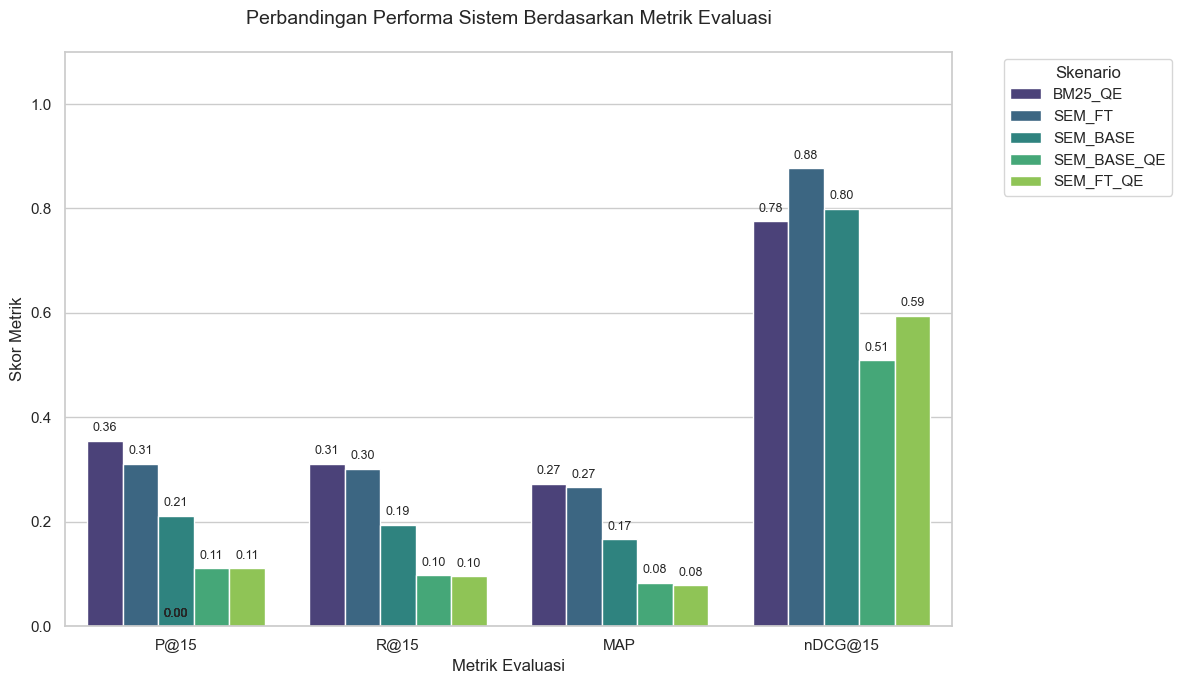

In [38]:
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Transform data agar mudah diplot
df_plot = eval_df.melt(id_vars="system", var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_plot, x="Metric", y="Value", hue="system", palette="viridis")

# Tambahkan label nilai di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

plt.title("Perbandingan Performa Sistem Berdasarkan Metrik Evaluasi", fontsize=14, pad=20)
plt.ylim(0, 1.1) # nDCG sering mendekati 1
plt.ylabel("Skor Metrik")
plt.xlabel("Metrik Evaluasi")
plt.legend(title="Skenario", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

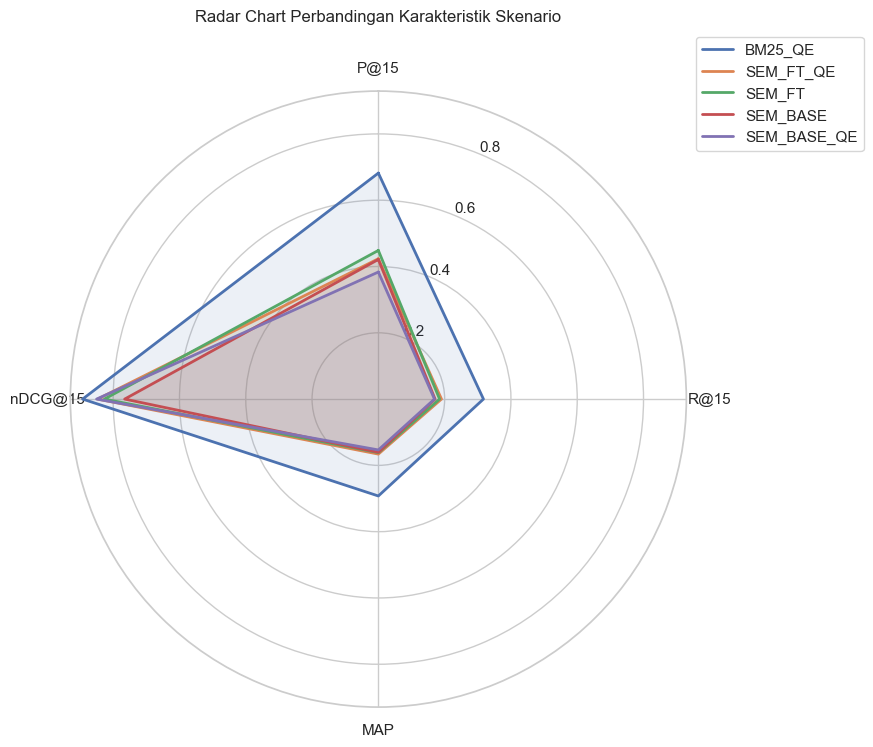

In [151]:
def plot_radar_chart(df):
    labels = df.columns[1:]
    num_vars = len(labels)
    
    # Sudut untuk setiap metrik
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] # Menutup lingkaran
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for i, row in df.iterrows():
        values = row[1:].tolist()
        values += values[:1] # Menutup lingkaran
        ax.plot(angles, values, linewidth=2, label=row['system'])
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    plt.title("Radar Chart Perbandingan Karakteristik Skenario", y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

plot_radar_chart(eval_df)

In [112]:
%pip install statsmodels
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa

# load data
df = pd.read_csv(
    "pool_for_judging_new - Copy.csv",
    sep=None,
    engine="python",
    encoding="utf-8",
    on_bad_lines="skip"
)

# ambil hanya kolom anotator
ratings = df[['relevance 1', 'relevance 2', 'relevance 3']].values

# ubah ke format Fleiss: jumlah vote per kategori
# kategori: 0,1,2
table = []

for row in ratings:
    counts = [0, 0, 0]  # untuk label 0,1,2
    for r in row:
        counts[int(r)] += 1
    table.append(counts)

table = np.array(table)

# hitung fleiss kappa
kappa = fleiss_kappa(table)

print("Fleiss' Kappa:", round(kappa, 4))

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.3 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.5 MB 2.2 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.1 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.5 MB 2.3 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.5 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.5 MB 2.6 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 2.6 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.5 MB 2.8 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 2.8 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 2.7 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.5 MB 2.8 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Fleiss' Kappa: 0.3789


In [113]:
# P_bar adalah rata-rata kesepakatan nyata (Overall Agreement)
overall_agreement = P_bar * 100

print(f"Overall Agreement: {overall_agreement:.2f}%")
print(f"Fleiss' Kappa: {round(kappa, 4)}")

Overall Agreement: 59.40%
Fleiss' Kappa: 0.3789


In [115]:
# p adalah variabel proporsi yang sudah ada di kodemu sebelumnya
for i, val in enumerate(p):
    print(f"Proporsi kategori {i}: {round(val * 100, 2)}%")

print(f"Nilai Pe (Peluang Kebetulan): {round(P_e, 4)}")

Proporsi kategori 0: 28.2%
Proporsi kategori 1: 29.18%
Proporsi kategori 2: 42.63%
Nilai Pe (Peluang Kebetulan): 0.3463


In [114]:
# Menghitung baris yang ketiga raternya setuju 100%
unanimous = np.sum(P == 1.0)
percentage_unanimous = (unanimous / N) * 100

print(f"Kesepakatan Bulat (3 Rater sama): {unanimous} baris ({percentage_unanimous:.2f}%)")

Kesepakatan Bulat (3 Rater sama): 454 baris (43.20%)


In [85]:
import numpy as np
import pandas as pd

# 1) pastikan tipe data aman
df["qid"] = df["qid"].astype(int)
df["doc_id"] = df["doc_id"].astype(int)
df["rank_in_system"] = df["rank_in_system"].astype(int)
df["relevance"] = df["relevance"].astype(int)

# 2) bikin tipe query: keyword vs konseptual (aturan super simpel)
def query_type(q: str) -> str:
    q = str(q).strip().lower()
    # heuristik: kalau <= 3 kata → biasanya keyword, sisanya konseptual
    n_words = len(q.split())
    return "KEYWORD" if n_words <= 3 else "KONSEPTUAL"

qinfo = df[["qid","query"]].drop_duplicates().copy()
qinfo["qtype"] = qinfo["query"].apply(query_type)

print(qinfo["qtype"].value_counts())
qinfo.head()


qtype
KEYWORD       21
KONSEPTUAL     1
Name: count, dtype: int64


,qid,query,qtype
0,1,audit internal,KEYWORD
42,2,budaya organisasi,KEYWORD
86,3,investasi asing,KEYWORD
120,4,pemasaran hasil tani,KEYWORD
176,5,pengendalian hama terpadu,KEYWORD


In [86]:
def precision_at_k(ranked_docs, rel_docs, k):
    if k == 0: 
        return 0.0
    return sum(1 for d in ranked_docs[:k] if d in rel_docs) / k

def recall_at_k(ranked_docs, rel_docs, k):
    if len(rel_docs) == 0:
        return 0.0
    return sum(1 for d in ranked_docs[:k] if d in rel_docs) / len(rel_docs)

def average_precision(ranked_docs, rel_docs):
    if not rel_docs:
        return 0.0
    score, hits = 0.0, 0
    for i, d in enumerate(ranked_docs, 1):
        if d in rel_docs:
            hits += 1
            score += hits / i
    return score / len(rel_docs)

def dcg_at_k(rels, k):
    return sum((2**rel - 1) / np.log2(i+2) for i, rel in enumerate(rels[:k]))

def ndcg_at_k(ranked_docs, rel_map, k):
    rels = [rel_map.get(d, 0) for d in ranked_docs[:k]]
    ideal = sorted(rel_map.values(), reverse=True)
    idcg = dcg_at_k(ideal, k)
    return 0.0 if idcg == 0 else dcg_at_k(rels, k) / idcg


In [87]:
def evaluate(df_pool, qinfo, K=10):
    # anggap relevan untuk P/R/MAP jika relevance >= 1
    qrels = df_pool[df_pool["relevance"] > 0][["qid","doc_id","relevance"]].copy()
    systems = df_pool["system"].unique()

    out_rows = []

    for sys in systems:
        df_sys = df_pool[df_pool["system"] == sys]

        for qtype in ["ALL", "KEYWORD", "KONSEPTUAL"]:
            if qtype == "ALL":
                qids = df_sys["qid"].unique()
            else:
                qids = qinfo[qinfo["qtype"] == qtype]["qid"].unique()

            p_list, r_list, ap_list, ndcg_list = [], [], [], []

            for qid in qids:
                df_q = df_sys[df_sys["qid"] == qid].sort_values("rank_in_system")
                if df_q.empty:
                    continue

                ranked = df_q["doc_id"].astype(int).tolist()

                rel_docs = set(qrels[qrels["qid"] == qid]["doc_id"].astype(int))
                rel_map = dict(zip(
                    qrels[qrels["qid"] == qid]["doc_id"].astype(int),
                    qrels[qrels["qid"] == qid]["relevance"].astype(int)
                ))

                p_list.append(precision_at_k(ranked, rel_docs, K))
                r_list.append(recall_at_k(ranked, rel_docs, K))
                ap_list.append(average_precision(ranked, rel_docs))
                ndcg_list.append(ndcg_at_k(ranked, rel_map, K))

            if len(p_list) == 0:
                continue

            out_rows.append({
                "group": qtype,
                "system": sys,
                f"P@{K}": float(np.mean(p_list)),
                f"R@{K}": float(np.mean(r_list)),
                "MAP": float(np.mean(ap_list)),
                f"nDCG@{K}": float(np.mean(ndcg_list)),
                "n_queries": int(len(qids)),
            })

    return pd.DataFrame(out_rows)

# gabung qtype ke pool (biar gampang filter)
df2 = df.merge(qinfo, on=["qid","query"], how="left")

eval10 = evaluate(df2, qinfo, K=10)
eval50 = evaluate(df2, qinfo, K=50)

print("=== ALL (K=10) ===")
display(eval10[eval10["group"]=="ALL"].sort_values("nDCG@10", ascending=False))

print("=== KEYWORD vs KONSEPTUAL (K=10) ===")
display(eval10[eval10["group"]!="ALL"].sort_values(["group","nDCG@10"], ascending=False))

print("=== ALL (K=50) ===")
display(eval50[eval50["group"]=="ALL"].sort_values("nDCG@50", ascending=False))


=== ALL (K=10) ===


,group,system,P@10,R@10,MAP,nDCG@10,n_queries
6,ALL,BM25_QE,0.827273,0.260776,0.298344,0.720087,22
12,ALL,SEM_FT,0.600000,0.163346,0.162272,0.496788,22
9,ALL,SEM_FT_QE,0.555000,0.159281,0.152019,0.479616,20
0,ALL,SEM_BASE,0.581818,0.158589,0.157493,0.440948,22
3,ALL,SEM_BASE_QE,0.570000,0.173352,0.154827,0.436963,20


=== KEYWORD vs KONSEPTUAL (K=10) ===


,group,system,P@10,R@10,MAP,nDCG@10,n_queries
14,KONSEPTUAL,SEM_FT,1.000000,0.250000,0.250000,0.811178,1
2,KONSEPTUAL,SEM_BASE,0.800000,0.200000,0.185008,0.586228,1
8,KONSEPTUAL,BM25_QE,0.800000,0.200000,0.257551,0.490596,1
11,KONSEPTUAL,SEM_FT_QE,0.500000,0.125000,0.120833,0.453365,1
5,KONSEPTUAL,SEM_BASE_QE,0.400000,0.100000,0.073333,0.368050,1
7,KEYWORD,BM25_QE,0.828571,0.263670,0.300287,0.731015,21
13,KEYWORD,SEM_FT,0.580952,0.159219,0.158095,0.481817,21
10,KEYWORD,SEM_FT_QE,0.557895,0.161085,0.153660,0.480997,21
4,KEYWORD,SEM_BASE_QE,0.578947,0.177212,0.159116,0.440590,21
1,KEYWORD,SEM_BASE,0.571429,0.156617,0.156182,0.434030,21


=== ALL (K=50) ===


,group,system,P@50,R@50,MAP,nDCG@50,n_queries
6,ALL,BM25_QE,0.203636,0.328615,0.298344,0.460347,22
9,ALL,SEM_FT_QE,0.120000,0.177686,0.152019,0.280182,20
12,ALL,SEM_FT,0.133636,0.183254,0.162272,0.280135,22
0,ALL,SEM_BASE,0.124545,0.169005,0.157493,0.245078,22
3,ALL,SEM_BASE_QE,0.114000,0.173352,0.154827,0.242004,20
